In [131]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
RESULTS_DIR = os.getcwd() + "/../results/H/safe_risky/"
RESULTS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky/'

In [132]:
fpath = Path(RESULTS_DIR) / "full-results.csv"
print(fpath)
res_df = pd.read_csv(fpath)

/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky/full-results.csv


In [133]:
# --- Basic cleaning ---
res_df = res_df.rename(columns={
    "time_mean (s)": "time",
    "time_std (s)": "time_std",
    "episodes_mean": "episodes"
})

cols = ["H", "episodes", "episodes_std", "time", "time_std"]
res_df = res_df.loc[:, cols]
res_df = res_df.sort_values("H")
for c in cols:
    res_df[c] = pd.to_numeric(res_df[c], errors="coerce")
res_df = res_df[res_df['H'] < 11]

res_df = (
    res_df.replace(["#DIV/0!", ""], np.nan)  # Excel errors + empty strings
      .replace(r'^\s*$', np.nan, regex=True)  # whitespace
      .fillna(0)
)
res_df

,H,episodes,episodes_std,time,time_std
0,1,445.5,3.535534,0.381964,0.066807
1,3,122797.0,12.727922,205.079591,10.814103
2,5,459755.0,431.335136,1481.368033,55.843574
3,7,1034522.0,388.908730,3208.278334,79.793286
4,9,1800539.0,0.000000,8871.236556,112.138072


In [134]:
H_LOGS_DIR = os.getcwd() + "/../logs/H/safe_risky4"

Hs = [1, 3, 5, 7, 9]
total_samples = []

for H in Hs:
    df = pd.read_csv(Path(H_LOGS_DIR) / f"safe_risky4_{H}.csv")    
    df["numSamples"] = pd.to_numeric(df["numSamples"], errors="coerce").fillna(0)

    # total episodes from summary df
    final_episodes = res_df.loc[res_df["H"] == H, "episodes"].values[0]

    # split last row
    last_row = df.iloc[-1]
    last_episode_logged = last_row["episode"]
    last_numSamples = last_row["numSamples"]

    # sum all except last row
    total = (10 * df.iloc[:-1]["numSamples"]).sum()

    # add corrected last row contribution
    remaining_episodes = final_episodes - last_episode_logged + 1
    total += remaining_episodes * 10 * last_numSamples

    total_samples.append(total)

Hs = np.array(Hs)
total_samples = np.array(total_samples)

In [136]:
res_df['total_samples'] = total_samples
res_df

,H,episodes,episodes_std,time,time_std,total_samples
0,1,445.5,3.535534,0.381964,0.066807,22440.0
1,3,122797.0,12.727922,205.079591,10.814103,11608780.0
2,5,459755.0,431.335136,1481.368033,55.843574,49888280.0
3,7,1034522.0,388.908730,3208.278334,79.793286,137219890.0
4,9,1800539.0,0.000000,8871.236556,112.138072,295320470.0


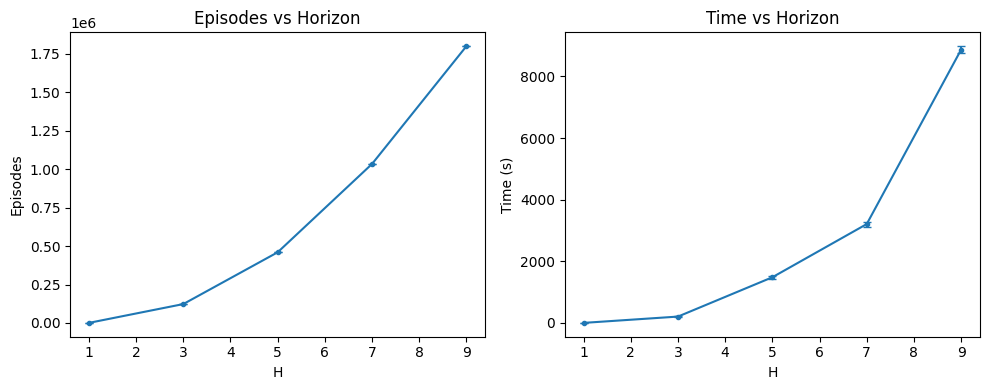

Saved plot to /Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../results/H/safe_risky/safe_risky_complexity.pdf


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Episodes vs H
axes[0].errorbar(df["H"], df["episodes"], yerr=df["episodes_std"], 
                 marker='o', markersize=3, capsize=3)
axes[0].set_xlabel("H")
axes[0].set_ylabel("Episodes")
axes[0].set_title("Episodes vs Horizon")
# axes[0].set_xscale("log")
# axes[0].set_yscale("log")  # important for scaling laws

# Time vs H
axes[1].errorbar(df["H"], df["time"], yerr=df["time_std"], 
                 marker='o', markersize=3, capsize=3)
axes[1].set_xlabel("H")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Time vs Horizon")
# axes[1].set_xscale("log")
# axes[1].set_yscale("log")

plt.tight_layout()

# --- Save ---
output_path = Path(RESULTS_DIR) / "safe_risky_complexity.pdf"
plt.savefig(output_path)
plt.show()
plt.close()

print(f"Saved plot to {output_path}")

- episode vs. H: polynomial + constants might dominate for small H
- execution time vs. H: looks more expensive
  - number of samples increase per episode (each of length H) -> per-episode cost $\approx H\cdot N^\omega_t$

## Complexity in $\varepsilon$

In [119]:
LOGS_DIR = os.getcwd() + "/../logs/H/"
LOGS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/H/'

In [118]:
log_df = pd.read_csv(Path(LOGS_DIR) / "safe_risky2.csv")

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,coverage,numSamples
0,1,9.000000,2.000000,1.685576,16,1.00,51
1,2,9.000000,2.000000,1.314521,16,1.00,73
2,3,9.000000,1.946382,1.091399,16,1.00,85
3,4,8.758718,1.669403,0.931003,16,1.00,93
4,5,7.512315,1.361977,0.816157,16,1.00,99
...,...,...,...,...,...,...,...
488447,488448,0.025000,0.005556,0.003475,4,0.25,83
488448,488449,0.025000,0.005556,0.003475,4,0.25,83
488449,488450,0.025000,0.005556,0.003475,4,0.25,83
488450,488451,0.025000,0.005556,0.003475,4,0.25,83
